# Data Exploration - Notebook

In [ ]:
import numpy as np                ## linear algebra
import pandas as pd               ## data processing, dataset file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt   ## data visualization & graphical plotting
import seaborn as sns             ## to visualize random distributions
import plotly.express as px       ## data visualization & graphical plotting
import squarify                   ## Treemap plots

%matplotlib inline
from plotly.subplots import make_subplots
from plotly.offline import init_notebook_mode

pd.options.display.float_format = '{:.2f}'.format  ## limiting the decimals in the output to 2 

import warnings                    ## Filter warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

df = pd.read_csv('../data/earthquake_data.csv')

df.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN


Dataset Columns

In [19]:
print(f'Number of records (rows) in the dataset are: {df.shape[0]}')
print(f'Number of features (columns) in the dataset are: {df.shape[1]}')
print(f'Number of duplicate entries in the dataset are: {df.duplicated().sum()}')
print(f'Number missing values in the dataset are: {sum(df.isna().sum())}')

Number of records (rows) in the dataset are: 782
Number of features (columns) in the dataset are: 19
Number of duplicate entries in the dataset are: 0
Number missing values in the dataset are: 1246


## Basic Overview

In [5]:
df.shape
df.dtypes
df.info()

df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      782 non-null    str    
 1   magnitude  782 non-null    float64
 2   date_time  782 non-null    str    
 3   cdi        782 non-null    int64  
 4   mmi        782 non-null    int64  
 5   alert      415 non-null    str    
 6   tsunami    782 non-null    int64  
 7   sig        782 non-null    int64  
 8   net        782 non-null    str    
 9   nst        782 non-null    int64  
 10  dmin       782 non-null    float64
 11  gap        782 non-null    float64
 12  magType    782 non-null    str    
 13  depth      782 non-null    float64
 14  latitude   782 non-null    float64
 15  longitude  782 non-null    float64
 16  location   777 non-null    str    
 17  continent  206 non-null    str    
 18  country    484 non-null    str    
dtypes: float64(6), int64(5), str(8)
memory usage: 185.1 KB


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.5960,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.7380,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.3460,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.1290,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.2780,NaN,NaN,NaN
5,M 7.0 - south of the Fiji Islands,7.0,09-11-2022 09:51,4,3,green,1,755,us,142,4.578,26.0,mwb,660.000,-26.0442,178.3810,the Fiji Islands,NaN,NaN
6,M 6.8 - south of the Fiji Islands,6.8,09-11-2022 09:38,1,3,green,1,711,us,136,4.678,22.0,mww,630.379,-25.9678,178.3630,the Fiji Islands,NaN,NaN
7,"M 6.7 - 60 km SSW of Boca Chica, Panama",6.7,20-10-2022 11:57,7,6,green,1,797,us,145,1.151,37.0,mww,20.000,7.6712,-82.3396,"Boca Chica, Panama",NaN,Panama
8,"M 6.8 - 55 km SSW of Aguililla, Mexico",6.8,22-09-2022 06:16,8,7,yellow,1,1179,us,175,2.137,92.0,mww,20.000,18.3300,-102.9130,"Aguililla, Mexico",North America,Mexico
9,"M 7.6 - 35 km SSW of Aguililla, Mexico",7.6,19-09-2022 18:05,9,8,yellow,1,1799,us,271,1.153,69.0,mww,26.943,18.3667,-103.2520,"Aguililla, Mexico",North America,Mexico


## Data Quality Checks

In [21]:
df.isnull().sum()[df.isnull().sum() > 0]

alert        367
location       5
continent    576
country      298
dtype: int64

Location has 5 missing values, whereas, alert, continent and country have hundreds of missing values each.

## Summary Statistics

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,782,768,M 6.9 -,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
magnitude,782.0,NaN,NaN,NaN,6.941125,0.445514,6.5,6.6,6.8,7.1,9.1
date_time,782,773,11-01-2022 12:39,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cdi,782.0,NaN,NaN,NaN,4.33376,3.169939,0.0,0.0,5.0,7.0,9.0
mmi,782.0,NaN,NaN,NaN,5.964194,1.462724,1.0,5.0,6.0,7.0,9.0
alert,415,4,green,325,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tsunami,782.0,NaN,NaN,NaN,0.388747,0.487778,0.0,0.0,0.0,1.0,1.0
sig,782.0,NaN,NaN,NaN,870.108696,322.465367,650.0,691.0,754.0,909.75,2910.0
net,782,11,us,747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nst,782.0,NaN,NaN,NaN,230.250639,250.188177,0.0,0.0,140.0,445.0,934.0


## Column Detection Helpers

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [9]:
date_col = "date_time"
mag_col = "magnitude"
depth_col = "depth"
lat_col = "latitude"
lon_col = "longitude"

date_col, mag_col, depth_col, lat_col, lon_col

('date_time', 'magnitude', 'depth', 'latitude', 'longitude')

## Time-Based Analysis

In [13]:
if date_col:
    df[date_col] = pd.to_datetime(
        df[date_col],
        errors="coerce",
        format="%d-%m-%Y %H:%M",
        dayfirst=True,
    )
    date_range = (df[date_col].min(), df[date_col].max())
    print(date_range)
else:
    "No date-like column detected."

(Timestamp('2001-01-01 06:57:00'), Timestamp('2022-11-22 02:03:00'))


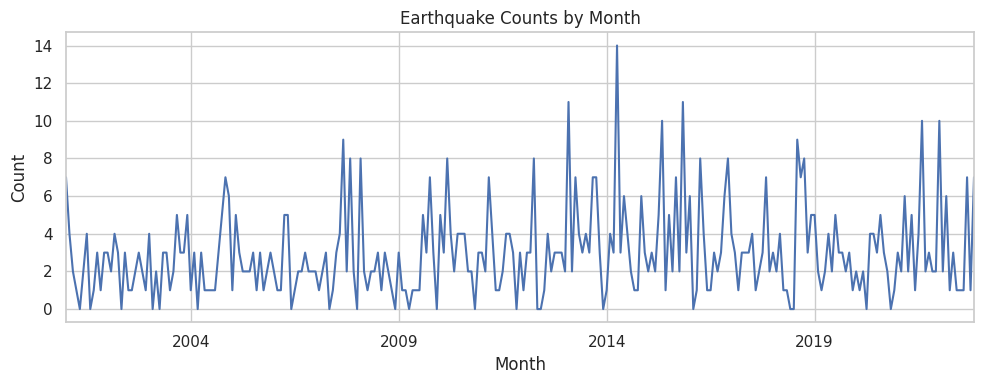

In [14]:
if date_col:
    (
        df.set_index(date_col)
        .resample("ME")
        .size()
        .plot(figsize=(10, 4), title="Earthquake Counts by Month")
    )
    plt.xlabel("Month")
    plt.ylabel("Count")
    plt.tight_layout()
else:
    "No date-like column detected."

## Magnitude and Depth Distributions

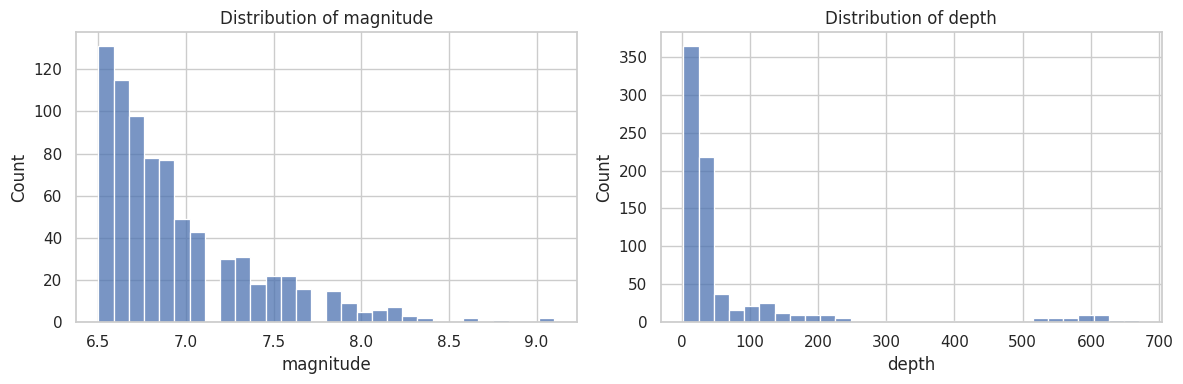

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if mag_col:
    sns.histplot(data=df, x=mag_col, bins=30, ax=axes[0])
    axes[0].set_title(f"Distribution of {mag_col}")
else:
    axes[0].text(0.5, 0.5, "No magnitude column detected", ha="center")
    axes[0].set_axis_off()

if depth_col:
    sns.histplot(data=df, x=depth_col, bins=30, ax=axes[1])
    axes[1].set_title(f"Distribution of {depth_col}")
else:
    axes[1].text(0.5, 0.5, "No depth column detected", ha="center")
    axes[1].set_axis_off()

plt.tight_layout()

## Relation b/w magnitude and depth & magnitude and significance

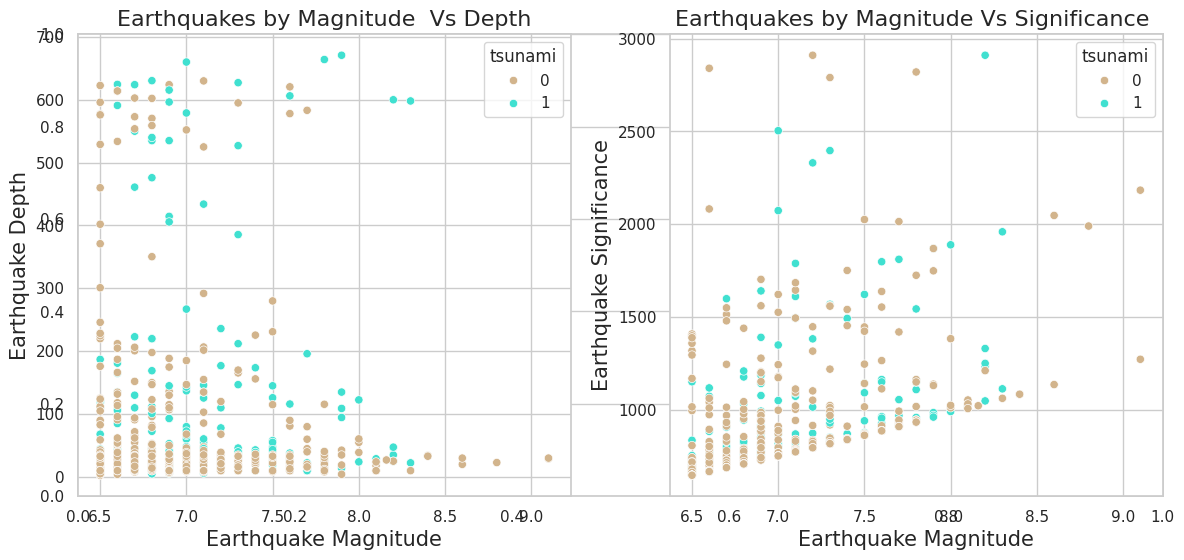

In [25]:
plt.subplots(figsize=(14,6))
my_pal = ('#D2B48C','#40E0D0')
          
plt.subplot(1,2,1)
plt.title('Earthquakes by Magnitude  Vs Depth',fontsize=16)
sns.scatterplot(data=df, x='magnitude', y='depth', hue='tsunami', palette=my_pal)
plt.ylabel('Earthquake Depth', fontsize=15)
plt.xlabel('Earthquake Magnitude', fontsize=15)

plt.subplot(1,2,2)
plt.title('Earthquakes by Magnitude Vs Significance ',fontsize=16)
sns.scatterplot(data=df, x='magnitude', y='sig', hue='tsunami', palette=my_pal)
plt.ylabel('Earthquake Significance', fontsize=15)
plt.xlabel('Earthquake Magnitude', fontsize=15)

plt.show()

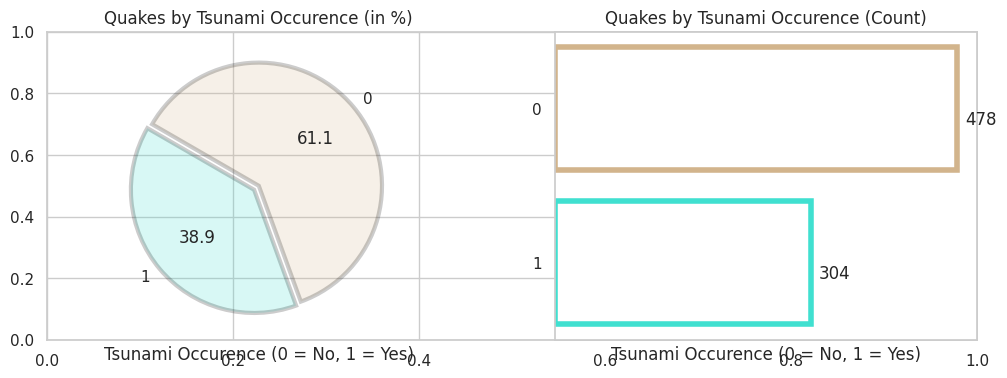

In [29]:
plt.subplots(figsize=(12,4))

my_col = ["#D2B48C", "#40E0D0"]

plt.subplot(1,2,1)
plt.title('Quakes by Tsunami Occurence (in %)',fontsize=12)
my_xpl = [0.0, 0.05]
df['tsunami'].value_counts().plot(kind='pie', colors=my_col, explode=my_xpl, legend=None, ylabel='', counterclock=False, startangle=150, wedgeprops={'alpha':0.2, 'edgecolor' : 'black','linewidth': 3, 'antialiased': True}, autopct='%1.1f')
plt.xlabel('Tsunami Occurence (0 = No, 1 = Yes)',fontsize=12)

plt.subplot(1,2,2)
plt.title('Quakes by Tsunami Occurence (Count)',fontsize=12)
ax = sns.countplot(y='tsunami', data=df, facecolor=(1,1,1,1), linewidth=4, edgecolor=sns.color_palette(my_col, 2), order=df['tsunami'].value_counts().index)

for p in ax.patches:
    ax.annotate('{:.0f}'.format(p.get_width()),  (p.get_x() + p.get_width() + 10, p.get_y()+0.5))

plt.xlabel('Tsunami Occurence (0 = No, 1 = Yes)',fontsize=12)
plt.xticks([]), plt.ylabel(None)
    
plt.show()

## Spatial Scatter

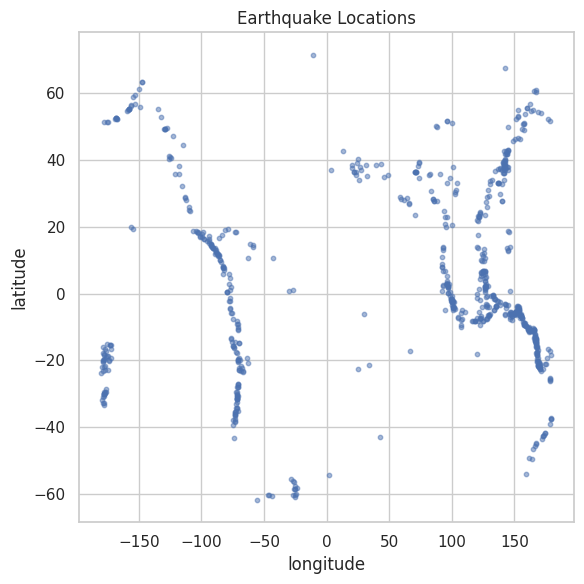

In [17]:
if lat_col and lon_col:
    plt.figure(figsize=(6, 6))
    plt.scatter(df[lon_col], df[lat_col], s=10, alpha=0.5)
    plt.xlabel(lon_col)
    plt.ylabel(lat_col)
    plt.title("Earthquake Locations")
    plt.tight_layout()
else:
    "No latitude/longitude columns detected."

## Correlation Heatmap (Numeric Columns)

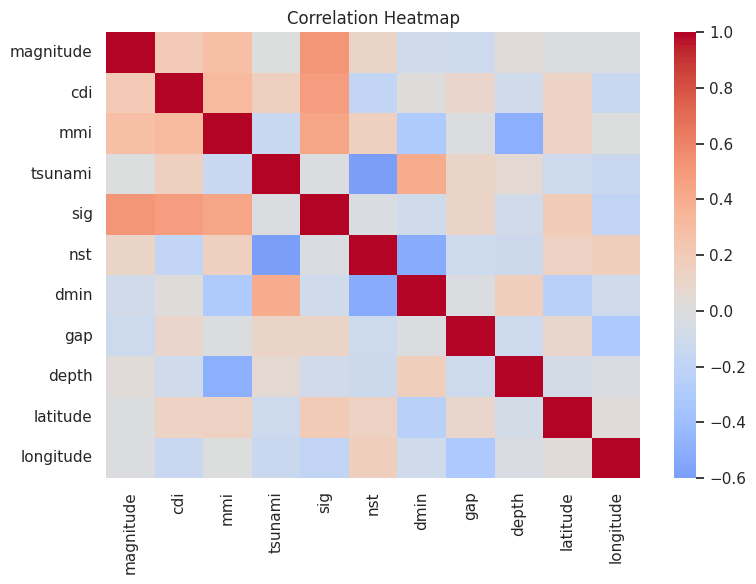

In [30]:
numeric_df = df.select_dtypes(include="number")
if numeric_df.shape[1] >= 2:
    corr = numeric_df.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
else:
    "Not enough numeric columns for correlation."

In [33]:
import folium
from folium import plugins

In [34]:
print("Earthquakes Across the World  -  Heat Map")
world = folium.Map(location=[df["latitude"].mean(), df["longitude"].mean()], zoom_start=2)
heat_map = df[["latitude", "longitude"]].values
world.add_child(plugins.HeatMap(heat_map, min_opacity=0.3, radius=13))
world

Earthquakes Across the World  -  Heat Map
